In [11]:
import numpy as np;
import matplotlib.pyplot as plt

from PIL import Image
import tensorflow as tf

In [9]:
img1 = Image.open(f"data/Normal/Normal-1.png")
img1 = img1.convert("L")
img1 = np.array(img1)
img1 = img1 / 255

img2 = Image.open(f"data/Tuberculosis/Tuberculosis-1.png")
img2 = img2.convert("L")
img2 = np.array(img2)
img2 = img2 / 255


# Collecting the Lung Photos

In [ ]:
lung_data = []
errors_id = []

# Normal - 3501 items
# Normal Chest X-Rays - 515 items
# TB - 701 items
# TB Chest X-rays - 2495 items

size_normal = 4100
size_tb = 3500


pixel_size = 256


# if(size_normal < 3501):
#     for i in range(1,size_normal+1):
#         img = Image.open(f"data/Normal/Normal-{i}.png")
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)

# else:
#     for i in range(1,3501):
#         img = Image.open(f"data/Normal/Normal-{i}.png")
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)
    
#     for i in range(1, size_normal - 3500 + 1):
#         try:
#             img = Image.open(f"data/Normal Chest X-rays/others ({i}).jpg")
#         except FileNotFoundError:
#             continue
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)

# if size_tb < 701:
#     for i in range(1,size_tb+1):
#         img = Image.open(f"data/Tuberculosis/Tuberculosis-{i}.png")
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)
# else:
#     for i in range(1,701):
#         img = Image.open(f"data/Tuberculosis/Tuberculosis-{i}.png")
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)

#     for i in range(1,size_tb - 700 + 1):
#         try:
#             img = Image.open(f"data/TB Chest X-rays/TB.{i}.jpg")
#         except FileNotFoundError:
#             continue
#         img = img.convert("L")
#         img = np.array(img)[int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2),int((512-pixel_size)/2):pixel_size+int((512-pixel_size)/2)]
#         img = img / 255
#         lung_data.append(img)


# [int((256-pixel_size)/2):pixel_size+int((256-pixel_size)/2),int((256-pixel_size)/2):pixel_size+int((256-pixel_size)/2)]
# for i in range(1, 701):
#     try:
#         img = Image.open(f"data/Normal Chest X-rays/others ({i}).jpg")
#     except FileNotFoundError:
#         continue
#     img = img.convert("L")
#     img = np.array(img)
#     img = img / 255
#     lung_data.append(img)

# print(len(lung_data))

# for i in range(1,701):
#     try:
#         img = Image.open(f"data/TB Chest X-rays/TB.{i}.jpg")
#     except FileNotFoundError:
#         continue
#     img = img.convert("L")
#     img = np.array(img)
#     img = img / 255
#     lung_data.append(img)

len(lung_data)

0

In [12]:

# for i, img in enumerate(lung_data):
#     # if img already a numpy array or PIL, convert and resize via PIL for consistent behavior
#     pil = Image.fromarray((img).astype(np.uint8)) if img.dtype != np.uint8 else Image.fromarray(img)
#     pil = pil.resize(target, resample=Image.BILINEAR)
#     arr = np.array(pil).astype(np.float32) / 255.0
#     lung_resized.append(arr)


lung_data = []
errors_id = []

# Normal - 3500 items
# Normal Chest X-Rays - 514 items
# TB - 700 items
# TB Chest X-rays - 2494 items

size_normal = 4100
size_tb = 3500

normal_true_size = 0
tb_true_size = 0


pixel_size = 256
pixel_size_for_large = 480

target = (pixel_size, pixel_size)  


if(size_normal < 3501):
    for i in range(1,2501):
        img = Image.open(f"data/Normal/Normal-{i}.png")
        img = img.convert("L")
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        normal_true_size += 1
        lung_data.append(img)
else:
    for i in range(1,3501):
        img = Image.open(f"data/Normal/Normal-{i}.png")
        img = img.convert("L")
        img = (np.array(img).astype(np.float32) / 255.0)
        y_size = img.shape[0]
        x_size = img.shape[1]
        img = img[int((y_size-pixel_size_for_large)/2):pixel_size_for_large+int((y_size-pixel_size_for_large)/2),int((x_size-pixel_size_for_large)/2):pixel_size_for_large+int((x_size-pixel_size_for_large)/2)]
        img = Image.fromarray((img * 255).astype(np.uint8)) if img.dtype != np.uint8 else Image.fromarray(img)
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        normal_true_size += 1
        lung_data.append(img)
    
    for i in range(1, size_normal - 3500 + 1):
        try:
            img = Image.open(f"data/Normal Chest X-rays/others ({i}).jpg")
        except FileNotFoundError:
            continue
        img = img.convert("L")
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        normal_true_size += 1
        lung_data.append(img)

if size_tb < 701:
    for i in range(1,size_tb+1):
        img = Image.open(f"data/Tuberculosis/Tuberculosis-{i}.png")
        img = img.convert("L")
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        tb_true_size += 1
        lung_data.append(img)
else:
    for i in range(1,701):
        img = Image.open(f"data/Tuberculosis/Tuberculosis-{i}.png")
        img = img.convert("L")
        img = (np.array(img).astype(np.float32) / 255.0)
        y_size = img.shape[0]
        x_size = img.shape[1]
        img = img[int((y_size-pixel_size_for_large)/2):pixel_size_for_large+int((y_size-pixel_size_for_large)/2),int((x_size-pixel_size_for_large)/2):pixel_size_for_large+int((x_size-pixel_size_for_large)/2)]
        img = Image.fromarray((img * 255).astype(np.uint8)) if img.dtype != np.uint8 else Image.fromarray(img)
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        tb_true_size += 1
        lung_data.append(img)

    for i in range(1,size_tb - 700 + 1):
        try:
            img = Image.open(f"data/TB Chest X-rays/TB.{i}.jpg")
        except FileNotFoundError:
            continue
        img = img.convert("L")
        img = img.resize(target, resample=Image.BILINEAR)
        img = np.array(img).astype(np.float32) / 255.0
        tb_true_size += 1
        lung_data.append(img)

In [61]:
len(lung_data)

7208

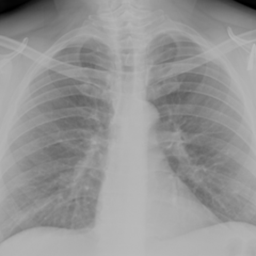

In [62]:
a = Image.fromarray((lung_data[normal_true_size+8]*255).astype(np.uint8))
a

In [14]:
lung_data = np.array(lung_data)

In [8]:
target = (pixel_size, pixel_size)  # (256,256)

lung_resized = []
for i, img in enumerate(lung_data):
    # if img already a numpy array or PIL, convert and resize via PIL for consistent behavior
    pil = Image.fromarray((img * 255).astype(np.uint8)) if img.dtype != np.uint8 else Image.fromarray(img)
    pil = pil.resize(target, resample=Image.BILINEAR)
    arr = np.array(pil).astype(np.float32) / 255.0
    lung_resized.append(arr)

lung_data_np = np.stack(lung_resized, axis=0)  # shape (N, 256, 256)
print("stacked shape:", lung_data_np.shape)

stacked shape: (7208, 256, 256)


#### 0 - Normal lung
#### 1 - tuberculez lung

In [9]:
normal_true_size, tb_true_size

(4014, 3194)

In [13]:
from keras.utils import to_categorical

lung_output = np.array([0 if i < normal_true_size+1 else 1 for i in range(1,normal_true_size+tb_true_size+1)])
lung_output

array([0, 0, 0, ..., 1, 1, 1], shape=(7208,))

(512, 512)


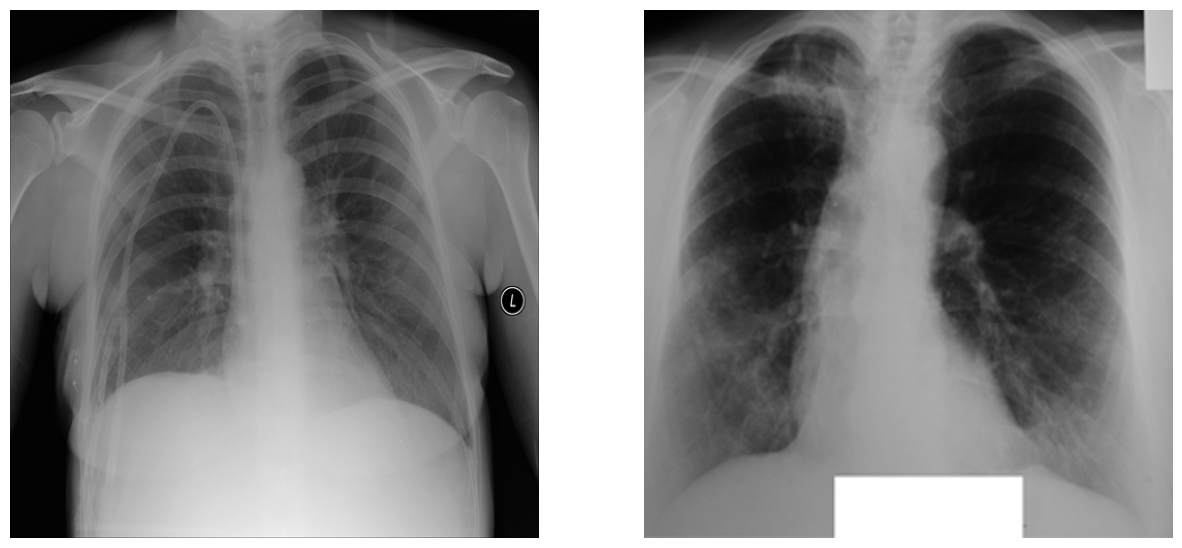

In [46]:
img_size_visual = [img1, img2]
img_size_visual = np.array(img_size_visual)

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

print(img1.shape)
for i in range(2):
    ax[i].imshow(img_size_visual[i], cmap='gray')
    ax[i].axis('off')

(2, 256, 256)


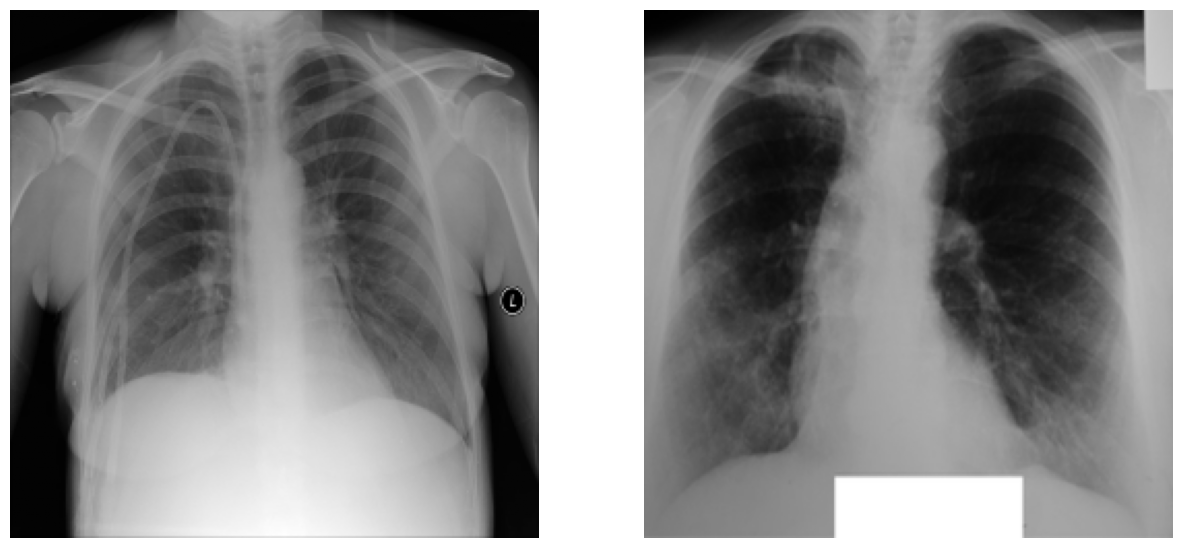

In [47]:

img_resized = tf.image.resize(img_size_visual[..., np.newaxis], (256, 256))[..., 0]


fig, ax = plt.subplots(1, 2, figsize=(15, 10))
print(img_resized.shape)
for i in range(2):
    ax[i].imshow(img_resized[i], cmap='gray')
    ax[i].axis('off')


(2, 128, 128)


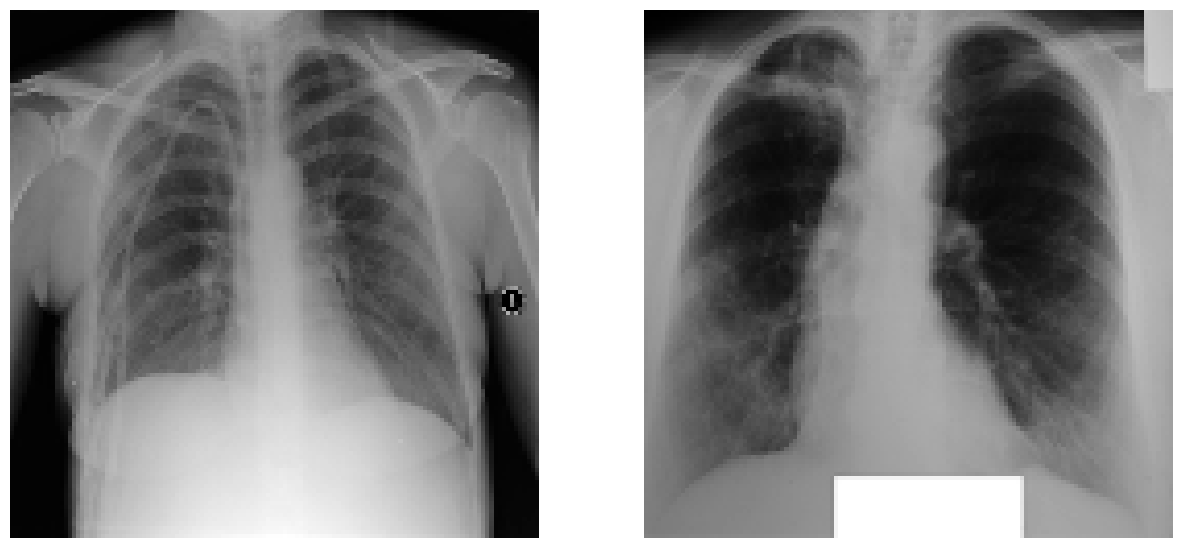

In [48]:

img_resized = tf.image.resize(img_size_visual[..., np.newaxis], (128, 128))[..., 0]


fig, ax = plt.subplots(1, 2, figsize=(15, 10))
print(img_resized.shape)

for i in range(2):
    ax[i].imshow(img_resized[i], cmap='gray')
    ax[i].axis('off')

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(lung_data, lung_output, test_size=0.2, shuffle=True, random_state=9)

In [15]:
from keras.utils import Sequence


class DataGenerator(Sequence):
    def __init__(self, data, label, batch_size=32):
        self.data = data
        self.label = label
        self.batch_size = batch_size
    
    def __len__(self):
        return int(np.round(len(self.data)/self.batch_size))
    
    def __getitem__(self, index):
        X = self.data[index * self.batch_size : (index + 1) * self.batch_size]
        y = self.label[index * self.batch_size : (index + 1) * self.batch_size]

        return X, y
    

In [51]:
from keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


# train_datagen = DataGenerator(X_train, y_train_cat)
# test_datagen = DataGenerator(X_test, y_test_cat)

In [66]:
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Input, Softmax
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
import random


In [ ]:

random.seed(9)
np.random.seed(9)
tf.random.set_seed(9)

# input = Input(X_train.shape[1:])
# flatten = Flatten()(input)
# dense1 = Dense(128, activation="relu")(flatten)
# dense2 = Dense(64, activation="relu")(dense1)
# dense3 = Dense(32, activation="relu")(dense2)
# dense4 = Dense(16, activation="relu")(dense3)
# dense5 = Dense(2, activation="linear")(dense4)
# output = Softmax()(dense5)

# model = Model(inputs=input, outputs=output)

model = Sequential([
    Flatten(input_shape=(256,256)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2,activation="sigmoid"),
])

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=BinaryCrossentropy(from_logits=False), metrics=["accuracy","recall","precision"])

model.summary()

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,399,634 (32.04 MB)

 Trainable params: 8,399,634 (32.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()

[array([[-7.7604200e-03,  5.5534793e-03, -8.8096308e-03, ...,
          1.0841172e-03, -1.9713701e-03,  7.7004693e-03],
        [ 2.3129117e-03, -6.6996682e-03, -1.5193112e-03, ...,
          2.0694826e-03,  8.7569971e-03,  3.4412732e-03],
        [ 2.1843258e-03,  9.8538399e-04,  5.2150143e-03, ...,
         -2.3944760e-03,  3.7516654e-04,  6.2022023e-03],
        ...,
        [-4.3726354e-03,  4.9743345e-03,  7.8647640e-03, ...,
          2.5544530e-03, -1.8133596e-03,  7.7634417e-03],
        [-3.7343106e-03,  9.2072599e-03, -2.2250316e-03, ...,
          7.6325405e-03, -2.1822564e-03, -3.5396507e-03],
        [ 5.0747460e-03, -6.4364634e-05,  6.4765140e-03, ...,
         -2.0552138e-03,  7.4409693e-03, -4.3254616e-03]],
       shape=(65536, 128), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [ ]:
history = model.fit(train_datagen, epochs=10, batch_size=64, validation_data=test_datagen)

Epoch 1/10


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0037 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0043 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0033 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0048 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0039 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0043 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0024 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0035 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0024 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0035 - val_preci

In [ ]:
history.history
# val_accuracy: 0.9399 - val_loss: 0.1558 - val_precision: 0.9399 - val_recall: 0.939

{'accuracy': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'loss': [0.003686137031763792,
  0.0033162313047796488,
  0.0038584102876484394,
  0.002417563693597913,
  0.0023916366044431925,
  0.0029041627421975136,
  0.0021475949324667454,
  0.0018102650064975023,
  0.0019698510877788067,
  0.0018000886775553226],
 'precision': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'recall': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'val_accuracy': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'val_loss': [0.00429642666131258,
  0.0048235380090773106,
  0.004288212861865759,
  0.00351355061866343,
  0.0035446560941636562,
  0.0031480547040700912,
  0.002993346191942692,
  0.0028330404311418533,
  0.0028981727082282305,
  0.0026007313281297684],
 'val_precision': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'val_recall': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}

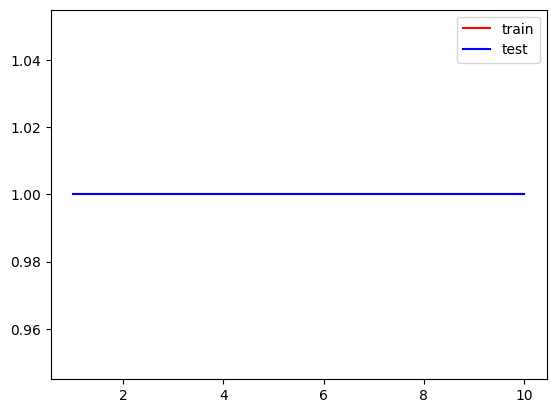

In [ ]:
plt.plot(range(1,len(history.history["loss"])+1), history.history["recall"], color="red", label="train")
plt.plot(range(1,len(history.history["loss"])+1), history.history["val_recall"], color="blue", label="test")
plt.legend()
plt.show()

In [67]:
from keras.layers import Conv2D, MaxPooling2D
import random

random.seed(9)
np.random.seed(9)
tf.random.set_seed(9)

input = Input(shape=(pixel_size,pixel_size,1))
x = Conv2D(filters=8,kernel_size=3, activation="relu", padding="valid")(input)
x = MaxPooling2D()(x)
x = Conv2D(filters=16,kernel_size=3, activation="relu", padding="valid")(x)
flatten = Flatten()(x)
x = Dense(32, activation="relu")(flatten)
x = Dense(16, activation="relu")(x)
x = Dense(2, activation="linear")(x)
output = Softmax()(x)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 250000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     8,000,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,842 (30.52 MB)

 Trainable params: 8,001,842 (30.52 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
from keras.losses import CategoricalCrossentropy
model.compile(optimizer="adam", loss=CategoricalCrossentropy(from_logits=False), metrics=["recall", "accuracy"])

In [16]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
X_train, X_test, y_train, y_test = train_test_split(np.array(lung_data), lung_output, test_size=0.2, shuffle=True, random_state=9)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

train_datagen = DataGenerator(X_train, y_train_cat)
test_datagen = DataGenerator(X_test, y_test_cat)

In [70]:
from keras import callbacks

model_checkpoint = callbacks.ModelCheckpoint(
    filepath="model_best_{epoch}.h5",
    monitor="val_recall",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch"
)

In [71]:
history = model.fit(train_datagen, epochs=15, validation_data=test_datagen, callbacks=[model_checkpoint])

Epoch 1/15


/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7986 - loss: 0.6052 - recall: 0.7986
Epoch 1: val_recall improved from None to 0.96389, saving model to model_best_1.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8891 - loss: 0.2994 - recall: 0.8891 - val_accuracy: 0.9639 - val_loss: 0.1165 - val_recall: 0.9639
Epoch 2/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9587 - loss: 0.1145 - recall: 0.9587
Epoch 2: val_recall did not improve from 0.96389
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.9616 - loss: 0.1091 - recall: 0.9616 - val_accuracy: 0.9514 - val_loss: 0.1224 - val_recall: 0.9514
Epoch 3/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9732 - loss: 0.0784 - recall: 0.9732
Epoch 3: val_recall did not improve from 0.96389
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9759 - loss: 0.0698 - recall: 0.9759 - val_accuracy: 0.9632 - val_loss: 0.1050 - val_recall: 0.9632
Epoch 4/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9825 - loss: 0.0577 - recall: 0.9825
Epoch 4: val_recall improved from 0.96389 to 0.96667, saving model to model_best_4.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9819 - loss: 0.0545 - recall: 0.9819 - val_accuracy: 0.9667 - val_loss: 0.1006 - val_recall: 0.9667
Epoch 5/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9821 - loss: 0.0456 - recall: 0.9821
Epoch 5: val_recall did not improve from 0.96667
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9821 - loss: 0.0490 - recall: 0.9821 - val_accuracy: 0.9542 - val_loss: 0.1501 - val_recall: 0.9542
Epoch 6/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9770 - loss: 0.0652 - recall: 0.9770
Epoch 6: val_recall did not improve from 0.96667
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9828 - loss: 0.0509 - recall: 0.9828 - val_accuracy: 0.9660 - val_loss: 0.1047 - val_recall: 0.9660
Epoch 7/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9895 - loss: 0.0305 - recall: 0.9895
Epoch 7: val_recall improved from 0.96667 to 0.97361, saving model to model_best_7.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9911 - loss: 0.0278 - recall: 0.9911 - val_accuracy: 0.9736 - val_loss: 0.0938 - val_recall: 0.9736
Epoch 8/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9952 - loss: 0.0155 - recall: 0.9952
Epoch 8: val_recall did not improve from 0.97361
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.9955 - loss: 0.0149 - recall: 0.9955 - val_accuracy: 0.9736 - val_loss: 0.0964 - val_recall: 0.9736
Epoch 9/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9954 - loss: 0.0143 - recall: 0.9954
Epoch 9: val_recall did not improve from 0.97361
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.9913 - loss: 0.0258 - recall: 0.9913 - val_accuracy: 0.9424 - val_loss: 0.1558 - val_recall: 0.9424
Epoch 10/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9893 - loss: 0.0307 - recall: 0.9893
Epoch 10: val_recall improved from 0.97361 to 0.97708, saving model to model_best_10.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 48s 269ms/step - accuracy: 0.9901 - loss: 0.0275 - recall: 0.9901 - val_accuracy: 0.9771 - val_loss: 0.0750 - val_recall: 0.9771
Epoch 11/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9966 - loss: 0.0100 - recall: 0.9966
Epoch 11: val_recall did not improve from 0.97708
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9969 - loss: 0.0085 - recall: 0.9969 - val_accuracy: 0.9736 - val_loss: 0.0982 - val_recall: 0.9736
Epoch 12/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9948 - loss: 0.0132 - recall: 0.9948
Epoch 12: val_recall improved from 0.97708 to 0.97986, saving model to model_best_12.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9951 - loss: 0.0117 - recall: 0.9951 - val_accuracy: 0.9799 - val_loss: 0.0906 - val_recall: 0.9799
Epoch 13/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9993 - loss: 0.0027 - recall: 0.9993
Epoch 13: val_recall did not improve from 0.97986
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.9991 - loss: 0.0032 - recall: 0.9991 - val_accuracy: 0.9792 - val_loss: 0.0820 - val_recall: 0.9792
Epoch 14/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9992 - loss: 0.0027 - recall: 0.9992
Epoch 14: val_recall did not improve from 0.97986
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.9990 - loss: 0.0033 - recall: 0.9990 - val_accuracy: 0.9715 - val_loss: 0.1271 - val_recall: 0.9715
Epoch 15/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9968 - loss: 0.0110 - recall: 0.9968
Epoch 15: val_recall did not improve from 0.97986
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.9929 - 

In [7]:
def grad_cam(model, image, class_idx, layer_name='conv2d_1'):
    """
    Generate Grad-CAM heatmap for a specific class prediction.
    """
    # Ensure image has batch dimension and channel dimension
    if len(image.shape) == 2:
        image = image[np.newaxis, ..., np.newaxis]
    elif len(image.shape) == 3:
        image = image[np.newaxis, ...]
    
    # Cast image to float32
    image = tf.cast(image, tf.float32)
        
    # Get the score for target class
    with tf.GradientTape() as tape:
        tape.watch(image)  # Explicitly watch the input image
        # Get the target conv layer
        grad_model = tf.keras.Model(
            [model.inputs], 
            [model.get_layer(layer_name).output, model.output]
        )
        
        # Get conv output and predictions
        conv_output, predictions = grad_model(image)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        target = predictions[:, class_idx]

    # Get gradients
    grads = tape.gradient(target, conv_output)
    
    # Safe pooling operation
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    # Weight the channels by corresponding gradients
    cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_output[0]), axis=-1)
    
    # Apply ReLU and normalize
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-20)
    cam = cam.numpy()
    
    # Resize to original image size
    cam = cv2.resize(cam, (image.shape[1], image.shape[2]))
    
    return cam



# Function to display the heatmap
def display_gradcam(image, heatmap, alpha=0.4):
    """
    Display the original image and overlay the heatmap
    
    Args:
        image: Original image
        heatmap: Generated heatmap
        alpha: Transparency factor for the heatmap
    """
    plt.figure(figsize=(12, 4))
    
    # Display original image
    plt.subplot(131)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Display heatmap
    plt.subplot(132)
    plt.imshow(heatmap, cmap='jet')
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')
    
    # Display overlayed image
    plt.subplot(133)
    heatmap_colored = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlayed = np.float32(heatmap_colored) / 255
    overlayed = alpha * overlayed + (1 - alpha) * image[..., np.newaxis]
    overlayed = overlayed / np.max(overlayed)
    plt.imshow(overlayed)
    plt.title('Overlayed Image')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
import cv2

# Get a sample image from test set
# np.where(y_test == 1)

In [59]:
X_train.shape

(5766, 256, 256)

(256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
normal 30.19%
TB 69.81%
True: TB
Predict: TB


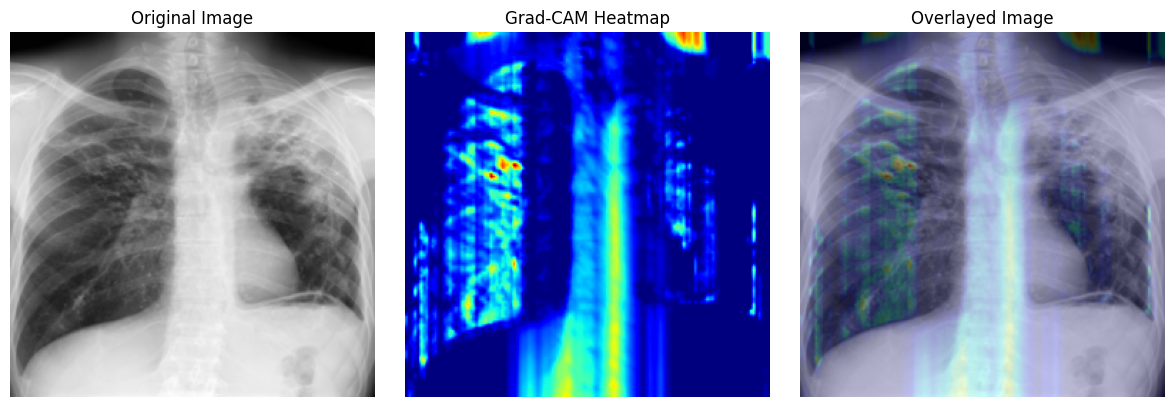

In [137]:


sample_idx = 85
sample_image = X_test[sample_idx]
print(sample_image.shape)
sample_pred = model.predict(sample_image[np.newaxis, ..., np.newaxis])
print(f"normal {sample_pred[0][0]*100:.2f}%")
print(f"TB {sample_pred[0][1]*100:.2f}%")
predicted_class = np.argmax(sample_pred[0])
print(f"True: {"TB" if y_test[sample_idx] == 1 else "Normal"}")
print(f"Predict: {"TB" if predicted_class == 1 else "Normal"}")

# Generate and display Grad-CAM
heatmap = grad_cam(model, sample_image, predicted_class,layer_name=model.layers[3].name)
heatmap
display_gradcam(sample_image, heatmap, alpha=0.2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[2.9615028e-06 9.9999702e-01]]
1


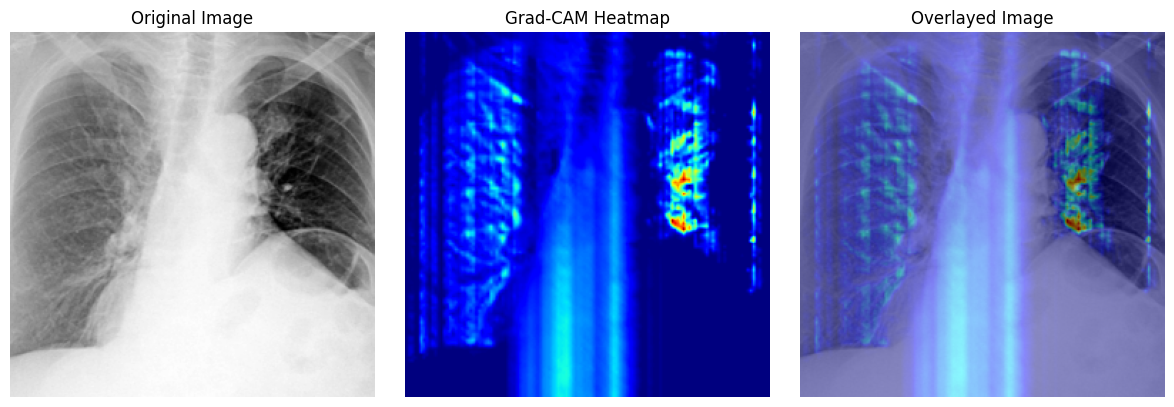

In [136]:
img_ex = Image.open(f"data/WhatsApp Image 2025-11-09 at 13.51.24.jpeg")

ex = np.array(img_ex)

img_ex = img_ex.convert("L")
# img_ex.show()
img_ex = np.array(img_ex)[int((630-pixel_size_for_large)/2):pixel_size_for_large+int((630-pixel_size_for_large)/2),int((696-pixel_size_for_large)/2):pixel_size_for_large+int((696-pixel_size_for_large)/2)]
img_ex = img_ex / 255


target = (pixel_size, pixel_size)  # (256,256)

pil = Image.fromarray((img_ex * 255).astype(np.uint8)) if img_ex.dtype != np.uint8 else Image.fromarray(img_ex)
pil = pil.resize(target, resample=Image.BILINEAR)
img_ex = np.array(pil).astype(np.float32) / 255.0
    

sample_pred = model.predict(img_ex[np.newaxis, ..., np.newaxis])
print(sample_pred)
predicted_class = np.argmax(sample_pred[0])
print(predicted_class)

# Generate and display Grad-CAM
heatmap = grad_cam(model, img_ex, predicted_class,layer_name=model.layers[3].name)
heatmap
display_gradcam(img_ex, heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
normal 1.48%
TB 98.52%
-------------------------
True: TB
Predict: TB


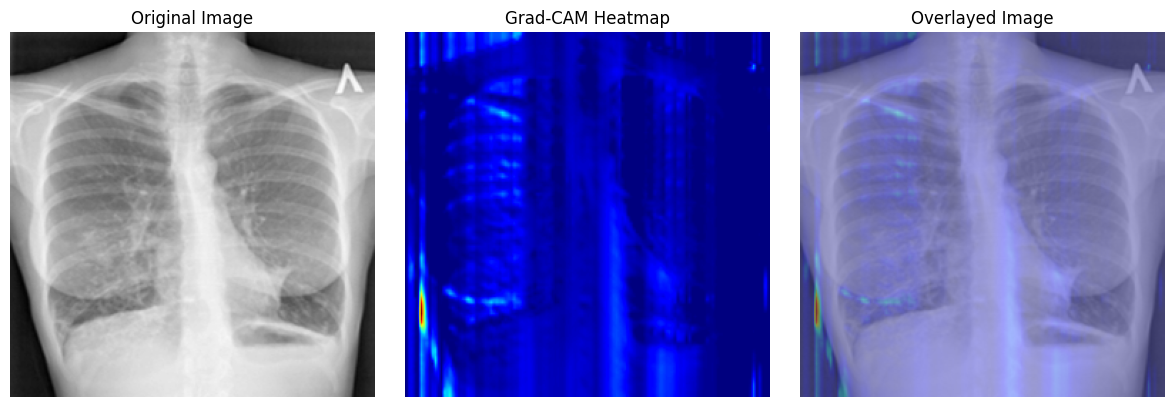

In [142]:

def img_predict(path:str, pixel_size=256, border_gap=16):
    img_ex1 = Image.open(path)
    img_ex1 = (np.array(img_ex1.convert("L")) / 255)
    y_size = img_ex1.shape[0]
    x_size = img_ex1.shape[1]

    img_ex1 = img_ex1[border_gap:y_size - border_gap,border_gap:x_size - border_gap]



    target = (pixel_size, pixel_size)  # (256,256)

    pil = Image.fromarray((img_ex1 * 255).astype(np.uint8)) if img_ex1.dtype != np.uint8 else Image.fromarray(img_ex1)
    pil = pil.resize(target, resample=Image.BILINEAR)
    img_ex1 = np.array(pil).astype(np.float32) / 255.0
        
    sample_pred = model.predict(img_ex1[np.newaxis, ..., np.newaxis])
    print(f"normal {sample_pred[0][0]*100:.2f}%")
    print(f"TB {sample_pred[0][1]*100:.2f}%")
    predicted_class = np.argmax(sample_pred[0])
    print("-"*25)
    print(f"True: {"TB" if path.count("T") > 0 else "Normal"}")
    print(f"Predict: {"TB" if predicted_class == 1 else "Normal"}")

    # Generate and display Grad-CAM
    heatmap = grad_cam(model, img_ex1, predicted_class,layer_name=model.layers[3].name)
    heatmap
    display_gradcam(img_ex1, heatmap, alpha=0.3)

img_predict("data/Tuberculosis/Tuberculosis-30.png")


In [20]:
import tensorflow as tf
model = tf.keras.models.load_model("models/model_best_12.h5")

In [44]:
target = (256, 256)
img = Image.open(f"data/Normal/Normal-1.png")
img = img.convert("L")
img = img.resize(target, resample=Image.BILINEAR)
img = np.array(img).astype(np.float32) / 255.0
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)

model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[9.9999964e-01, 3.3895634e-07]], dtype=float32)

In [45]:
img

array([[[[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.05490196],
         [0.05882353],
         [0.04313726]],

        [[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.01960784],
         [0.02352941],
         [0.01960784]],

        [[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.01568628],
         [0.01568628],
         [0.01176471]],

        ...,

        [[0.01568628],
         [0.01568628],
         [0.01568628],
         ...,
         [0.02745098],
         [0.02745098],
         [0.02745098]],

        [[0.01568628],
         [0.01568628],
         [0.01568628],
         ...,
         [0.03137255],
         [0.03137255],
         [0.03137255]],

        [[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.02745098],
         [0.02745098],
         [0.02745098]]]], shape=(1, 256, 256, 1), dtype=float32)

In [21]:
preds = []
for img_i in X_test:
    img_i = np.expand_dims(img_i, axis=-1)
    img_i = np.expand_dims(img_i, axis=0)
    pred = model.predict(img_i)
    pred_class = np.argmax(pred[0])
    preds.append(pred_class)
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/s

[np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.in

In [52]:
sum(preds == y_test)/len(preds)

np.float64(0.9798890429958391)

In [37]:
for i in test_datagen:
    print(i[0].shape)

(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)
(32, 256, 256)


In [1]:
text = """[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 83ms/step - accuracy: 0.8891 - loss: 0.2994 - recall: 0.8891 - val_accuracy: 0.9639 - val_loss: 0.1165 - val_recall: 0.9639
Epoch 2/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 79ms/step - accuracy: 0.9587 - loss: 0.1145 - recall: 0.9587
Epoch 2: val_recall did not improve from 0.96389
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 83ms/step - accuracy: 0.9616 - loss: 0.1091 - recall: 0.9616 - val_accuracy: 0.9514 - val_loss: 0.1224 - val_recall: 0.9514
Epoch 3/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 80ms/step - accuracy: 0.9732 - loss: 0.0784 - recall: 0.9732
Epoch 3: val_recall did not improve from 0.96389
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 85ms/step - accuracy: 0.9759 - loss: 0.0698 - recall: 0.9759 - val_accuracy: 0.9632 - val_loss: 0.1050 - val_recall: 0.9632
Epoch 4/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 81ms/step - accuracy: 0.9825 - loss: 0.0577 - recall: 0.9825
Epoch 4: val_recall improved from 0.96389 to 0.96667, saving model to model_best_4.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 86ms/step - accuracy: 0.9819 - loss: 0.0545 - recall: 0.9819 - val_accuracy: 0.9667 - val_loss: 0.1006 - val_recall: 0.9667
Epoch 5/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 82ms/step - accuracy: 0.9821 - loss: 0.0456 - recall: 0.9821
Epoch 5: val_recall did not improve from 0.96667
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 86ms/step - accuracy: 0.9821 - loss: 0.0490 - recall: 0.9821 - val_accuracy: 0.9542 - val_loss: 0.1501 - val_recall: 0.9542
Epoch 6/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 81ms/step - accuracy: 0.9770 - loss: 0.0652 - recall: 0.9770
Epoch 6: val_recall did not improve from 0.96667
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 85ms/step - accuracy: 0.9828 - loss: 0.0509 - recall: 0.9828 - val_accuracy: 0.9660 - val_loss: 0.1047 - val_recall: 0.9660
Epoch 7/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 82ms/step - accuracy: 0.9895 - loss: 0.0305 - recall: 0.9895
Epoch 7: val_recall improved from 0.96667 to 0.97361, saving model to model_best_7.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 86ms/step - accuracy: 0.9911 - loss: 0.0278 - recall: 0.9911 - val_accuracy: 0.9736 - val_loss: 0.0938 - val_recall: 0.9736
Epoch 8/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 82ms/step - accuracy: 0.9952 - loss: 0.0155 - recall: 0.9952
Epoch 8: val_recall did not improve from 0.97361
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 87ms/step - accuracy: 0.9955 - loss: 0.0149 - recall: 0.9955 - val_accuracy: 0.9736 - val_loss: 0.0964 - val_recall: 0.9736
Epoch 9/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 83ms/step - accuracy: 0.9954 - loss: 0.0143 - recall: 0.9954
Epoch 9: val_recall did not improve from 0.97361
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 88ms/step - accuracy: 0.9913 - loss: 0.0258 - recall: 0.9913 - val_accuracy: 0.9424 - val_loss: 0.1558 - val_recall: 0.9424
Epoch 10/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 265ms/step - accuracy: 0.9893 - loss: 0.0307 - recall: 0.9893
Epoch 10: val_recall improved from 0.97361 to 0.97708, saving model to model_best_10.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m48s[0m 269ms/step - accuracy: 0.9901 - loss: 0.0275 - recall: 0.9901 - val_accuracy: 0.9771 - val_loss: 0.0750 - val_recall: 0.9771
Epoch 11/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 81ms/step - accuracy: 0.9966 - loss: 0.0100 - recall: 0.9966
Epoch 11: val_recall did not improve from 0.97708
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 85ms/step - accuracy: 0.9969 - loss: 0.0085 - recall: 0.9969 - val_accuracy: 0.9736 - val_loss: 0.0982 - val_recall: 0.9736
Epoch 12/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 81ms/step - accuracy: 0.9948 - loss: 0.0132 - recall: 0.9948
Epoch 12: val_recall improved from 0.97708 to 0.97986, saving model to model_best_12.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m15s[0m 86ms/step - accuracy: 0.9951 - loss: 0.0117 - recall: 0.9951 - val_accuracy: 0.9799 - val_loss: 0.0906 - val_recall: 0.9799
Epoch 13/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 82ms/step - accuracy: 0.9993 - loss: 0.0027 - recall: 0.9993
Epoch 13: val_recall did not improve from 0.97986
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 87ms/step - accuracy: 0.9991 - loss: 0.0032 - recall: 0.9991 - val_accuracy: 0.9792 - val_loss: 0.0820 - val_recall: 0.9792
Epoch 14/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 83ms/step - accuracy: 0.9992 - loss: 0.0027 - recall: 0.9992
Epoch 14: val_recall did not improve from 0.97986
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 88ms/step - accuracy: 0.9990 - loss: 0.0033 - recall: 0.9990 - val_accuracy: 0.9715 - val_loss: 0.1271 - val_recall: 0.9715
Epoch 15/15
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m0s[0m 82ms/step - accuracy: 0.9968 - loss: 0.0110 - recall: 0.9968
Epoch 15: val_recall did not improve from 0.97986
[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m16s[0m 87ms/step - accuracy: 0.9929 - loss: 0.0224 - recall: 0.9929 - val_accuracy: 0.9639 - val_loss: 0.1052 - val_recall: 0.9639"""

In [2]:
text_array = text.replace("", "").replace("[1m180/180[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m ", "").split("\n")
text_array

['15s 83ms/step - accuracy: 0.8891 - loss: 0.2994 - recall: 0.8891 - val_accuracy: 0.9639 - val_loss: 0.1165 - val_recall: 0.9639',
 'Epoch 2/15',
 '0s 79ms/step - accuracy: 0.9587 - loss: 0.1145 - recall: 0.9587',
 'Epoch 2: val_recall did not improve from 0.96389',
 '15s 83ms/step - accuracy: 0.9616 - loss: 0.1091 - recall: 0.9616 - val_accuracy: 0.9514 - val_loss: 0.1224 - val_recall: 0.9514',
 'Epoch 3/15',
 '0s 80ms/step - accuracy: 0.9732 - loss: 0.0784 - recall: 0.9732',
 'Epoch 3: val_recall did not improve from 0.96389',
 '15s 85ms/step - accuracy: 0.9759 - loss: 0.0698 - recall: 0.9759 - val_accuracy: 0.9632 - val_loss: 0.1050 - val_recall: 0.9632',
 'Epoch 4/15',
 '0s 81ms/step - accuracy: 0.9825 - loss: 0.0577 - recall: 0.9825',
 'Epoch 4: val_recall improved from 0.96389 to 0.96667, saving model to model_best_4.h5',
 "WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We reco

In [3]:
text_array2 = []
for i in text_array:
    text_array2.append(i[i.find("-")+1:])

text_array2

[' accuracy: 0.8891 - loss: 0.2994 - recall: 0.8891 - val_accuracy: 0.9639 - val_loss: 0.1165 - val_recall: 0.9639',
 'Epoch 2/15',
 ' accuracy: 0.9587 - loss: 0.1145 - recall: 0.9587',
 'Epoch 2: val_recall did not improve from 0.96389',
 ' accuracy: 0.9616 - loss: 0.1091 - recall: 0.9616 - val_accuracy: 0.9514 - val_loss: 0.1224 - val_recall: 0.9514',
 'Epoch 3/15',
 ' accuracy: 0.9732 - loss: 0.0784 - recall: 0.9732',
 'Epoch 3: val_recall did not improve from 0.96389',
 ' accuracy: 0.9759 - loss: 0.0698 - recall: 0.9759 - val_accuracy: 0.9632 - val_loss: 0.1050 - val_recall: 0.9632',
 'Epoch 4/15',
 ' accuracy: 0.9825 - loss: 0.0577 - recall: 0.9825',
 'Epoch 4: val_recall improved from 0.96389 to 0.96667, saving model to model_best_4.h5',
 "WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `ke

In [4]:
len('Epoch 4: val_recall improved from 0.96389 to 0.96667, saving model to model_best_4.h5')

85

In [5]:

metrics = {'accuracy': [],
 'loss': [],
 'recall': [],
 'val_accuracy': [],
 'val_loss': [],
 'val_recall': []}

for i in text_array2:
    if len(i) > 90:
        if i[0] != "E" and i[0] != "W":
            for j in i[i.find("accuracy"):].split(" - "):
                temp = j.find(":")
                metrics[j[:temp]].append(float(j[temp+2:]))
metrics

{'accuracy': [0.8891,
  0.9616,
  0.9759,
  0.9819,
  0.9821,
  0.9828,
  0.9911,
  0.9955,
  0.9913,
  0.9901,
  0.9969,
  0.9951,
  0.9991,
  0.999,
  0.9929],
 'loss': [0.2994,
  0.1091,
  0.0698,
  0.0545,
  0.049,
  0.0509,
  0.0278,
  0.0149,
  0.0258,
  0.0275,
  0.0085,
  0.0117,
  0.0032,
  0.0033,
  0.0224],
 'recall': [0.8891,
  0.9616,
  0.9759,
  0.9819,
  0.9821,
  0.9828,
  0.9911,
  0.9955,
  0.9913,
  0.9901,
  0.9969,
  0.9951,
  0.9991,
  0.999,
  0.9929],
 'val_accuracy': [0.9639,
  0.9514,
  0.9632,
  0.9667,
  0.9542,
  0.966,
  0.9736,
  0.9736,
  0.9424,
  0.9771,
  0.9736,
  0.9799,
  0.9792,
  0.9715,
  0.9639],
 'val_loss': [0.1165,
  0.1224,
  0.105,
  0.1006,
  0.1501,
  0.1047,
  0.0938,
  0.0964,
  0.1558,
  0.075,
  0.0982,
  0.0906,
  0.082,
  0.1271,
  0.1052],
 'val_recall': [0.9639,
  0.9514,
  0.9632,
  0.9667,
  0.9542,
  0.966,
  0.9736,
  0.9736,
  0.9424,
  0.9771,
  0.9736,
  0.9799,
  0.9792,
  0.9715,
  0.9639]}

In [6]:
metrics["val_loss"]

[0.1165,
 0.1224,
 0.105,
 0.1006,
 0.1501,
 0.1047,
 0.0938,
 0.0964,
 0.1558,
 0.075,
 0.0982,
 0.0906,
 0.082,
 0.1271,
 0.1052]

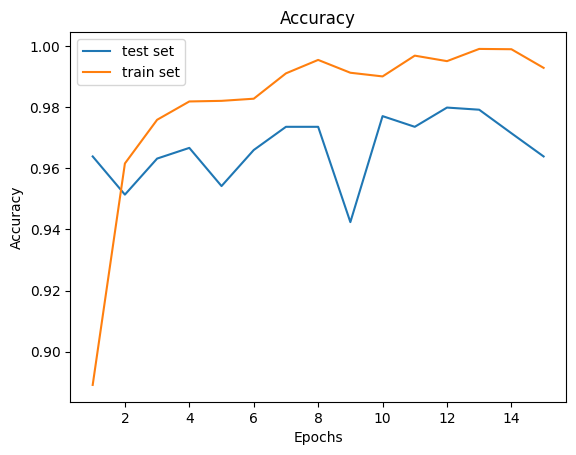

In [8]:
import matplotlib.pyplot as plt

metrics["epoch"] = list(range(1,16))


val_acc = metrics["val_accuracy"]
acc = metrics["accuracy"]
val_loss = metrics["val_loss"]
loss = metrics["loss"]
epoch = metrics["epoch"]

plt.plot(epoch, val_acc, label="test set")
plt.plot(epoch, acc, label="train set")

plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



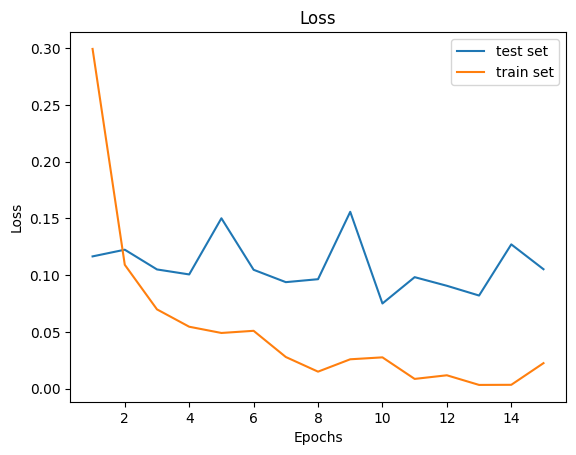

In [9]:
plt.plot(epoch, val_loss, label="test set")
plt.plot(epoch, loss, label="train set")

plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

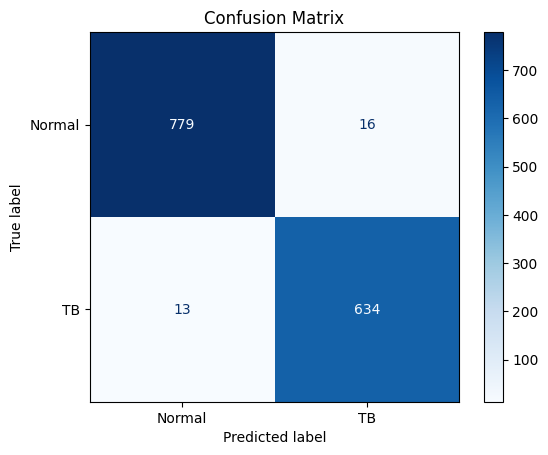

Confusion Matrix:
[[779  16]
 [ 13 634]]


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Create confusion matrix
cm = confusion_matrix(y_test, preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'TB'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:")
print(cm)

In [98]:
pred_class

np.int64(1)

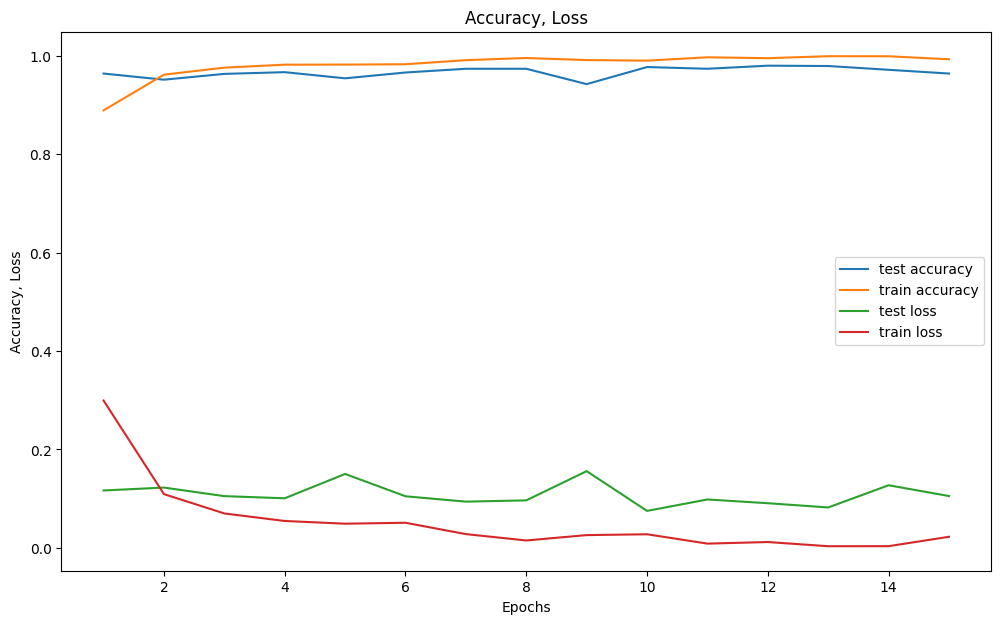

In [27]:
plt.figure(figsize=(12,7))

plt.plot(epoch, val_acc, label="test accuracy")
plt.plot(epoch, acc, label="train accuracy")

plt.plot(epoch, val_loss, label="test loss")
plt.plot(epoch, loss, label="train loss")


plt.title("Accuracy, Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy, Loss")
plt.legend()
plt.show()

In [5]:
import numpy as np

A = np.array([[5,4,3],
              [-1,0,-3],
              [1,-2,1]])

P = np.array([[1,1,-1],
             [-1,0,1],
             [1,0,1]])

P_inf = np.linalg.inv(P)

P_inf @ A @ P

array([[ 4.,  1.,  0.],
       [ 0.,  4.,  0.],
       [ 0.,  0., -2.]])

In [7]:
P_inf

array([[ 0. , -0.5,  0.5],
       [ 1. ,  1. ,  0. ],
       [ 0. ,  0.5,  0.5]])